In [1]:
import os
import random
import re
import time
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
precision_score, recall_score, roc_auc_score,
roc_curve)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

try:
    import nltk
    nltk.data.find('tokenizers/punkt')
except Exception:
    import nltk
    nltk.download('punkt')

from nltk.tokenize import word_tokenize

In [2]:
# Reproducibility helper
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
#Data loading
def load_csvs(use_title_plus_text=True):
    """Load Fake.csv and True.csv. This version REQUIRES the CSV files.
    Returns: list of texts, list of labels (1=fake, 0=real)
    """
    
    texts = []
    labels = []
    
    df_fake = pd.read_csv("Fake.csv")
    df_true = pd.read_csv("True.csv")
    
    def concat_row(r):
        if use_title_plus_text and 'title' in r and 'text' in r:
            return str(r.get('title', '')) + ' ' + str(r.get('text', ''))
        elif use_title_plus_text and 'Title' in r and 'Text' in r:
            return str(r.get('Title', '')) + ' ' + str(r.get('Text', ''))
        elif 'text' in r:
            return str(r.get('text', ''))
        elif 'Text' in r:
            return str(r.get('Text', ''))
        else:
            return ''

    for _, r in df_fake.iterrows():
        texts.append(concat_row(r))
        labels.append(1)
    
    for _, r in df_true.iterrows():
        texts.append(concat_row(r))
        labels.append(0)
    
    return texts, labels

In [4]:
#Minimal text cleaning
def clean_text(text):
    # Lowercase
    t = text.lower()
    # Replace URLs
    t = re.sub(r'http\S+|www\S+', ' ', t)
    # Remove digits and excessive punctuation (keep basic punctuation as separators)
    t = re.sub(r'[^a-z\s]', ' ', t)
    # Collapse whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    return t

In [5]:
#Tokenization 
def tokenize(text):
    return word_tokenize(text)

In [6]:
#Building vocabulary
def build_vocab(token_lists, max_size=20000, min_freq=1, reserved_tokens=None):
    if reserved_tokens is None:
        reserved_tokens = ['<PAD>', '<UNK>']
    counter = Counter()
    for tks in token_lists:
        counter.update(tks)
    # Keep tokens with freq >= min_freq
    items = [tok for tok, freq in counter.items() if freq >= min_freq]
    # Sort by freq
    items.sort(key=lambda x: -counter[x])
    items = items[:max_size]
    itos = reserved_tokens + items
    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos

In [7]:
#Text -> indices, padding/truncation
def tokens_to_indices(token_list, stoi, unk_token='<UNK>'):
    unk_idx = stoi.get(unk_token, 1)
    return [stoi.get(tok, unk_idx) for tok in token_list]

def pad_or_truncate(seq, max_len, pad_idx=0):
    if len(seq) >= max_len:
        return seq[:max_len]
    else:
        return seq + [pad_idx] * (max_len - len(seq))

In [8]:
#PyTorch Dataset and collate_fn
class NewsDataset(Dataset):
    def __init__(self, texts, labels, stoi, max_len=256):
        self.texts = texts
        self.labels = labels
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        toks = tokenize(clean_text(self.texts[idx]))
        inds = tokens_to_indices(toks, self.stoi)
        inds = pad_or_truncate(inds, self.max_len, pad_idx=0)
        return torch.tensor(inds, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_batch(batch):
    xs = torch.stack([b[0] for b in batch])
    ys = torch.stack([b[1] for b in batch])
    return xs, ys

In [9]:
#Model skeletons (RNN and LSTM)
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers,
                          batch_first=True, nonlinearity='tanh',
                          dropout=(dropout if num_layers > 1 else 0.0))
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        return torch.sigmoid(logits), logits

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=(dropout if num_layers > 1 else 0.0))
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
        self.bidirectional = bidirectional
        self.num_layers = num_layers

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        if self.bidirectional:
            # h_n shape: (num_layers * num_directions, batch, hidden)
            # take the last layer (two directions) and concat
            last_fw = h_n[-2]
            last_bw = h_n[-1]
            last = torch.cat([last_fw, last_bw], dim=1)
        else:
            last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        return torch.sigmoid(logits), logits

In [10]:
#Training and evaluation utilities
def train_epoch(model, dataloader, criterion, optimizer, device, clip_grad=5.0):
    model.train()
    losses = [] 
    preds = []
    trues = []
    start = time.time()
    
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        prob, logits = model(x_batch)
        
        loss = criterion(logits, y_batch.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        
        # record
        losses.append(loss.item())
        preds.extend((prob.detach().cpu().numpy() >= 0.5).astype(int).tolist())
        trues.extend(y_batch.detach().cpu().numpy().tolist())

    elapsed = time.time() - start
    return np.mean(losses), preds, trues, elapsed

def eval_model(model, dataloader, criterion, device):
    model.eval()
    losses = []
    preds_prob = []
    trues = []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            prob, logits = model(x_batch)
            loss = criterion(logits, y_batch.float())
            losses.append(loss.item())
            preds_prob.extend(prob.detach().cpu().numpy().tolist())
            trues.extend(y_batch.detach().cpu().numpy().tolist())
    return np.mean(losses), preds_prob, trues

def compute_metrics(y_true, y_pred_prob, threshold=0.5):
    y_pred = (np.array(y_pred_prob) >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred_prob)
    except Exception:
        auc = float('nan')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}

In [11]:
#Plotting helpers
def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_f1'], label='train_f1')
    plt.plot(epochs, history['val_f1'], label='val_f1')
    plt.xlabel('Epoch')
    plt.ylabel('F1')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion matrix')
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ['real', 'fake'])
    plt.yticks(ticks, ['real', 'fake'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def plot_roc(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('ROC Curve')
    plt.show()

In [12]:
#Orchestrator: build vocab, dataloaders, and train
def run_pipeline(use_title_plus_text=True,
                 max_vocab=20000, max_len=256,
                 batch_size=32, emb_dim=100, hidden_dim=128,
                 num_layers=1, bidirectional=False, dropout=0.2,
                 lr=1e-3, num_epochs=5, model_type='lstm', device=None):
    
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    
    texts, labels = load_csvs(use_title_plus_text)
    
    #Preprocess + tokenize all texts to build vocab
    token_lists = [tokenize(clean_text(t)) for t in texts]
    stoi, itos = build_vocab(token_lists, max_size=max_vocab)
    vocab_size = len(itos)
    print('Vocab size:', vocab_size)

    #Train/val/test split
    X_temp, X_test, y_temp, y_test = train_test_split(texts, labels, test_size=0.1, stratify=labels if len(set(labels))>1 else None, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp if len(set(y_temp))>1 else None, random_state=42) #0.1111 of 0.9 -> 0.1

    #Datasets & loaders
    train_ds = NewsDataset(X_train, y_train, stoi, max_len=max_len)
    val_ds = NewsDataset(X_val, y_val, stoi, max_len=max_len)
    test_ds = NewsDataset(X_test, y_test, stoi, max_len=max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

    # Model
    if model_type.lower() == 'rnn':
        model = SimpleRNNClassifier(vocab_size=vocab_size, emb_dim=emb_dim, hidden_dim=hidden_dim,
                                    num_layers=num_layers, dropout=dropout)
    else:
        model = LSTMClassifier(vocab_size=vocab_size, emb_dim=emb_dim, hidden_dim=hidden_dim,
                               num_layers=num_layers, bidirectional=bidirectional, dropout=dropout)
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    times_per_epoch = []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_preds, train_trues, elapsed = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_probs, val_trues = eval_model(model, val_loader, criterion, device)
        
        train_metrics = compute_metrics(train_trues, [int(p) for p in train_preds])
        # train_preds were ints so convert to list of probs for compute_metrics compatibility
        # For train F1 we'll compute from predicted labels
        train_f1 = train_metrics['f1']
        val_metrics = compute_metrics(val_trues, val_probs)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_metrics['f1'])
        times_per_epoch.append(elapsed)
    
        print(f"Epoch {epoch}/{num_epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_f1={train_f1:.4f}, val_f1={val_metrics['f1']:.4f}, time={elapsed:.2f}s")

    # Test evaluation
    test_loss, test_probs, test_trues = eval_model(model, test_loader, criterion, device)
    test_metrics = compute_metrics(test_trues, test_probs)
    print('\nTest results:')
    for k, v in test_metrics.items():
        print(f"{k}: {v}")

    # Plots
    plot_learning_curves(history)
    # Confusion matrix and ROC
    y_pred_labels = (np.array(test_probs) >= 0.5).astype(int)
    plot_confusion_matrix(test_trues, y_pred_labels)
    if len(set(test_trues)) > 1:
        plot_roc(test_trues, test_probs)
    else:
        print('Not enough label variety for ROC/AUC on test set.')

    # Return objects for further hyperparameter search/comparison
    return {
        'model': model,
        'stoi': stoi,
        'itos': itos,
        'history': history,
        'test_metrics': test_metrics,
        'times_per_epoch': times_per_epoch
    }

Using device: cpu
Vocab size: 5002
Epoch 1/4: train_loss=0.4195, val_loss=0.2267, train_f1=0.8368, val_f1=0.9406, time=290.91s
Epoch 2/4: train_loss=0.1221, val_loss=0.0255, train_f1=0.9670, val_f1=0.9959, time=337.57s
Epoch 3/4: train_loss=0.0246, val_loss=0.0239, train_f1=0.9956, val_f1=0.9960, time=297.74s
Epoch 4/4: train_loss=0.0147, val_loss=0.0211, train_f1=0.9974, val_f1=0.9964, time=312.35s

Test results:
accuracy: 0.9973273942093541
precision: 0.9991452991452991
recall: 0.995741056218058
f1: 0.9974402730375427
roc_auc: 0.9992440474202174


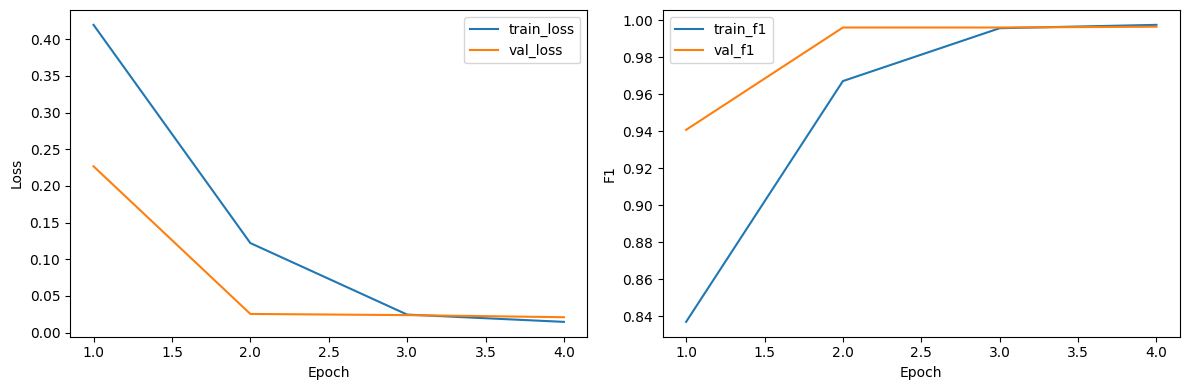

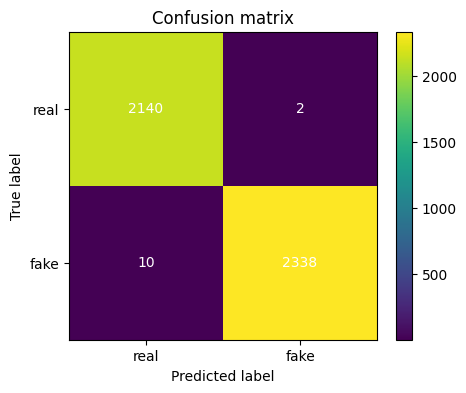

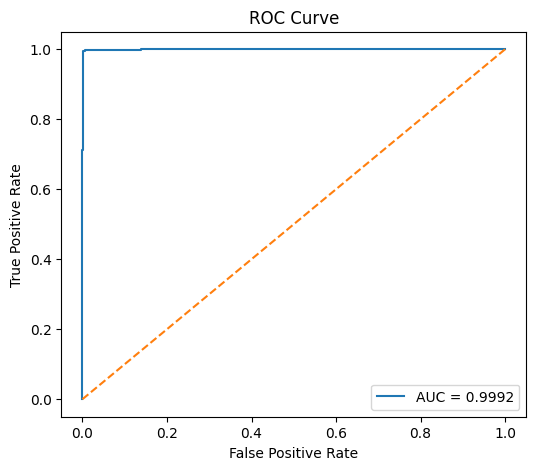

In [57]:
if __name__ == '__main__':
    results = run_pipeline(use_title_plus_text=True,
                           max_vocab=5000, max_len=128,
                           batch_size=16, emb_dim=100, hidden_dim=64,
                           num_layers=1, bidirectional=False, dropout=0.2,
                           lr=1e-3, num_epochs=4, model_type='lstm')

Using device: cpu
Vocab size: 5002
Epoch 1/4: train_loss=0.6556, val_loss=0.5028, train_f1=0.6504, val_f1=0.8072, time=254.46s
Epoch 2/4: train_loss=0.4386, val_loss=0.3915, train_f1=0.8241, val_f1=0.8519, time=244.80s
Epoch 3/4: train_loss=0.3975, val_loss=0.6146, train_f1=0.8465, val_f1=0.5291, time=317.93s
Epoch 4/4: train_loss=0.3437, val_loss=0.3223, train_f1=0.8658, val_f1=0.8736, time=276.41s

Test results:
accuracy: 0.8815144766146993
precision: 0.9344497607655502
recall: 0.8317717206132879
f1: 0.8801261829652997
roc_auc: 0.930343602517668


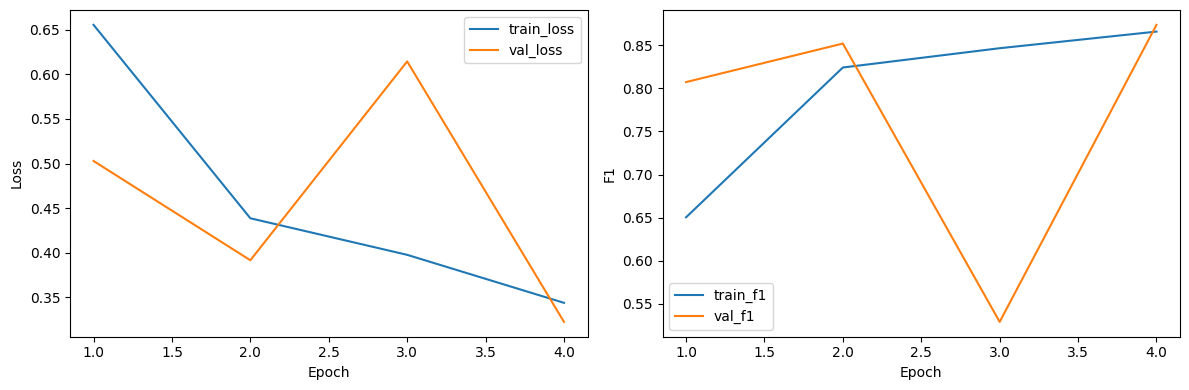

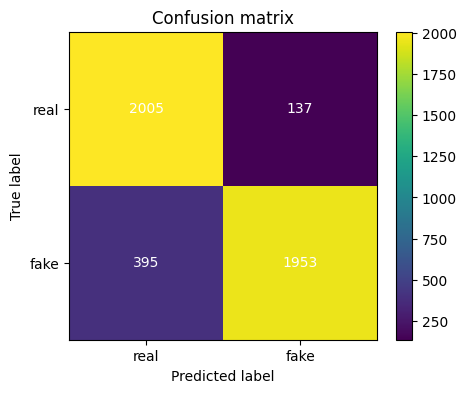

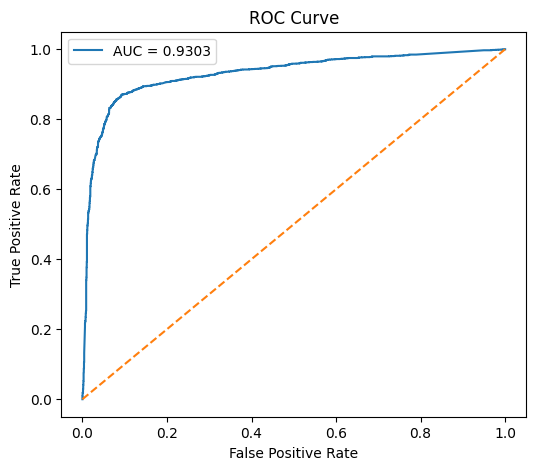

In [13]:
results_rnn = run_pipeline(use_title_plus_text=True,
                           max_vocab=5000, max_len=128,
                           batch_size=16, emb_dim=100, hidden_dim=64,
                           num_layers=1, bidirectional=False, dropout=0.2,
                           lr=1e-3, num_epochs=4, model_type='rnn')


Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.4686, val_loss=0.3048, train_f1=0.8118, val_f1=0.9099, time=160.57s
Epoch 2/3: train_loss=0.1963, val_loss=0.1601, train_f1=0.9451, val_f1=0.9157, time=165.27s
Epoch 3/3: train_loss=0.0578, val_loss=0.0282, train_f1=0.9831, val_f1=0.9955, time=168.62s

Test results:
accuracy: 0.9968819599109131
precision: 0.9978668941979523
recall: 0.9961669505962522
f1: 0.9970161977834613
roc_auc: 0.9979449900346283


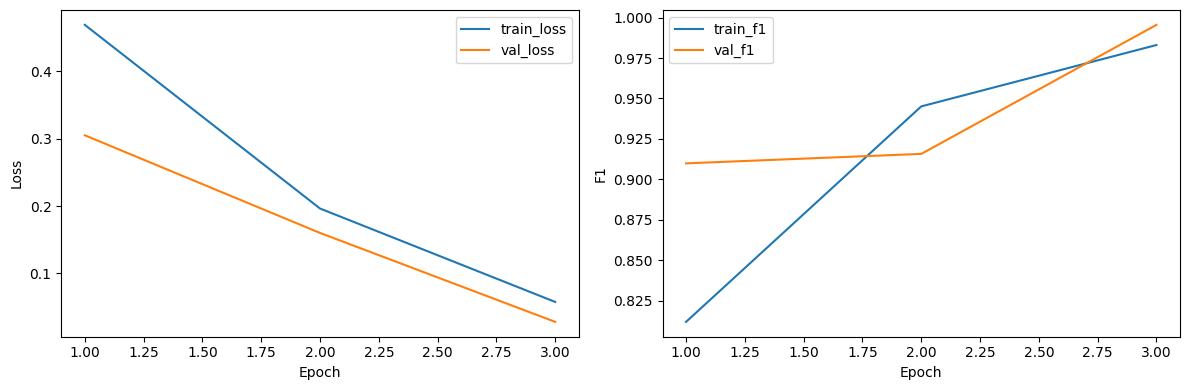

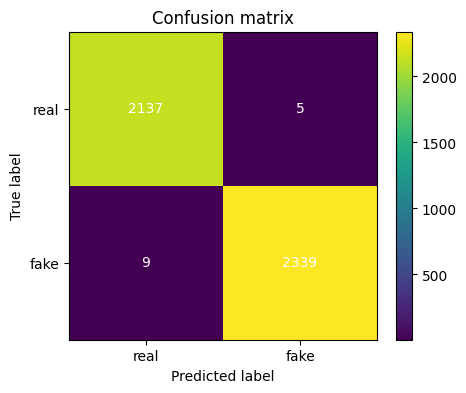

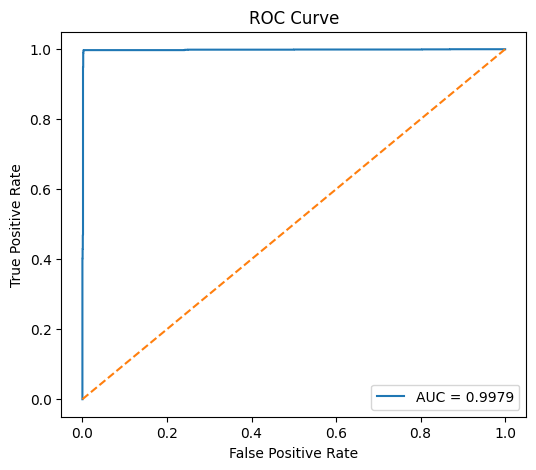

Summary: {'accuracy': 0.9968819599109131, 'precision': 0.9978668941979523, 'recall': 0.9961669505962522, 'f1': 0.9970161977834613, 'roc_auc': 0.9979449900346283, 'time_per_epoch': 164.8202284971873}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6439, val_loss=0.5386, train_f1=0.6602, val_f1=0.7382, time=261.81s
Epoch 2/3: train_loss=0.4745, val_loss=0.4831, train_f1=0.8089, val_f1=0.7972, time=267.91s
Epoch 3/3: train_loss=0.4073, val_loss=0.4751, train_f1=0.8546, val_f1=0.8167, time=278.23s

Test results:
accuracy: 0.8131403118040089
precision: 0.822298163178129
recall: 0.8198466780238501
f1: 0.8210705907442951
roc_auc: 0.8440539617323364


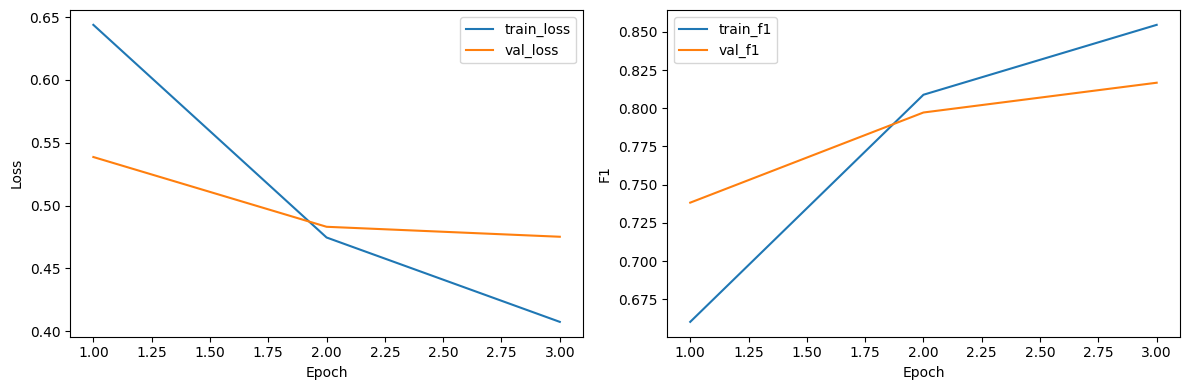

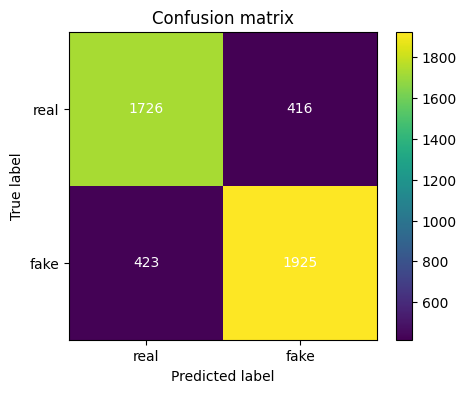

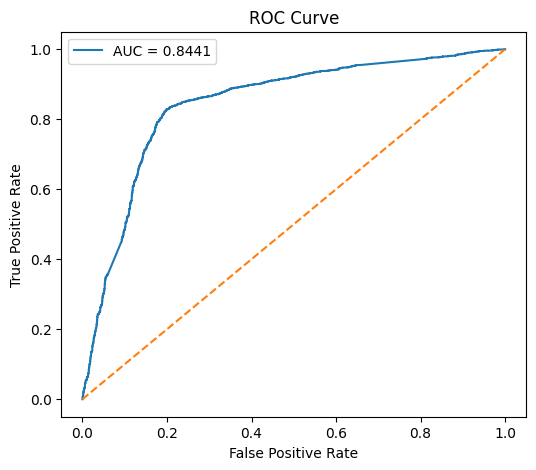

Summary: {'accuracy': 0.8131403118040089, 'precision': 0.822298163178129, 'recall': 0.8198466780238501, 'f1': 0.8210705907442951, 'roc_auc': 0.8440539617323364, 'time_per_epoch': 269.31567454338074}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.0005, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.3740, val_loss=0.1463, train_f1=0.8526, val_f1=0.9675, time=136.60s
Epoch 2/3: train_loss=0.1507, val_loss=0.0861, train_f1=0.9635, val_f1=0.9833, time=143.83s
Epoch 3/3: train_loss=0.0948, val_loss=0.0754, train_f1=0.9803, val_f1=0.9841, time=137.73s

Test results:
accuracy: 0.9799554565701559
precision: 0.9951754385964913
recall: 0.9663543441226575
f1: 0.9805531547104581
roc_auc: 0.9906858967323442


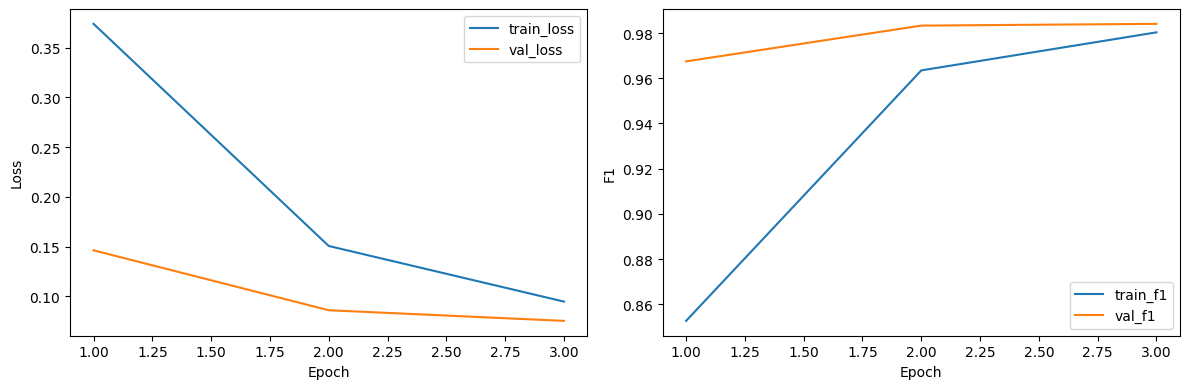

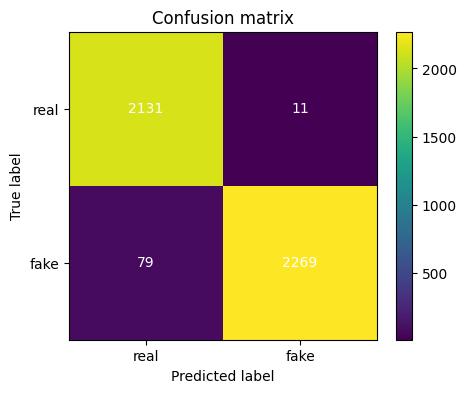

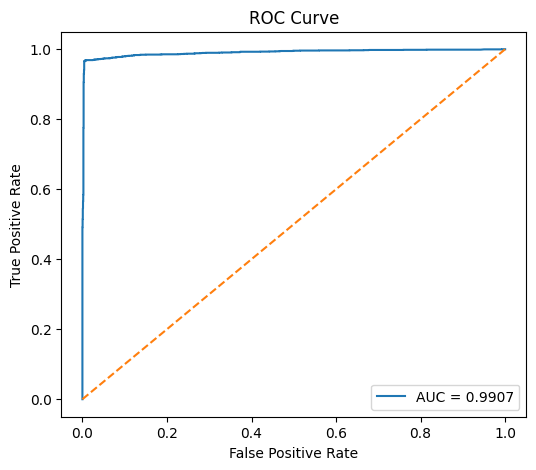

Summary: {'accuracy': 0.9799554565701559, 'precision': 0.9951754385964913, 'recall': 0.9663543441226575, 'f1': 0.9805531547104581, 'roc_auc': 0.9906858967323442, 'time_per_epoch': 139.3871021270752}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.0005, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6188, val_loss=0.5083, train_f1=0.7022, val_f1=0.7811, time=208.24s
Epoch 2/3: train_loss=0.4642, val_loss=0.4196, train_f1=0.8213, val_f1=0.8383, time=203.40s
Epoch 3/3: train_loss=0.4066, val_loss=0.3685, train_f1=0.8531, val_f1=0.8184, time=229.26s

Test results:
accuracy: 0.8334075723830735
precision: 0.9106776180698152
recall: 0.7555366269165247
f1: 0.8258845437616388
roc_auc: 0.9217994693618504


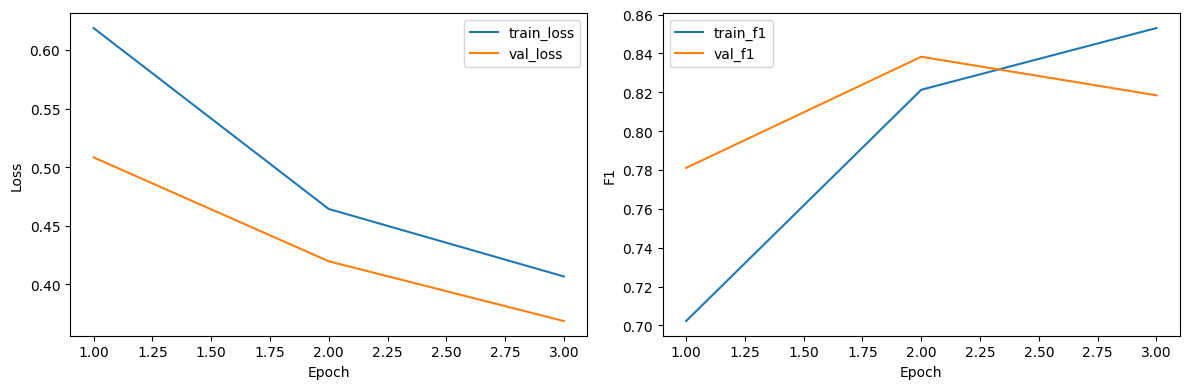

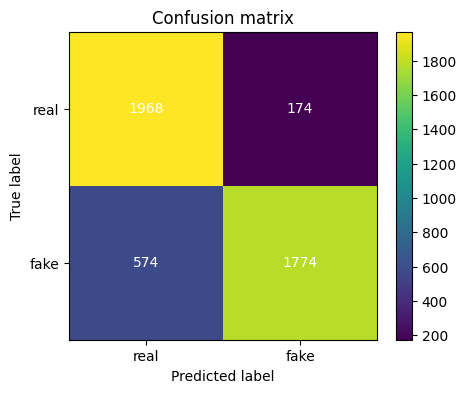

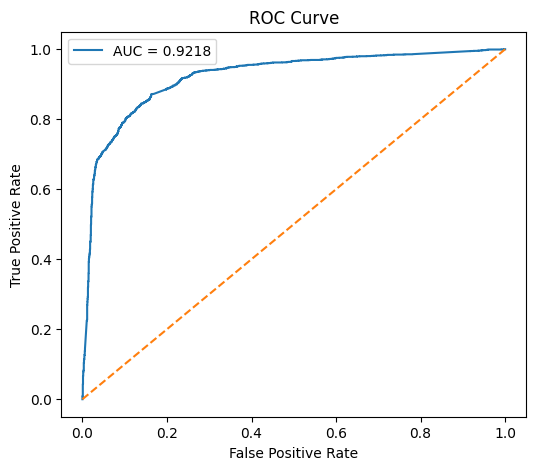

Summary: {'accuracy': 0.8334075723830735, 'precision': 0.9106776180698152, 'recall': 0.7555366269165247, 'f1': 0.8258845437616388, 'roc_auc': 0.9217994693618504, 'time_per_epoch': 213.63156048456827}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.001, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.4686, val_loss=0.3048, train_f1=0.8118, val_f1=0.9099, time=132.27s
Epoch 2/3: train_loss=0.1963, val_loss=0.1601, train_f1=0.9451, val_f1=0.9157, time=137.95s
Epoch 3/3: train_loss=0.0578, val_loss=0.0282, train_f1=0.9831, val_f1=0.9955, time=155.10s

Test results:
accuracy: 0.9968819599109131
precision: 0.9978668941979523
recall: 0.9961669505962522
f1: 0.9970161977834613
roc_auc: 0.9979449900346283


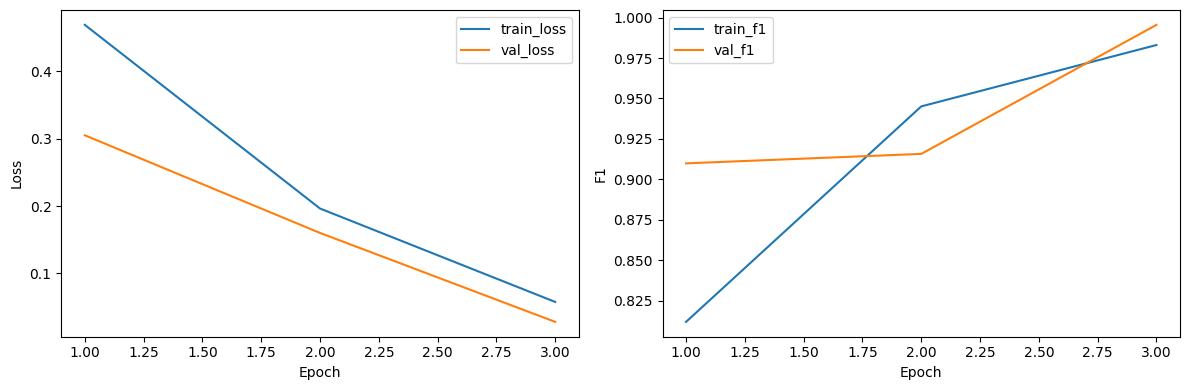

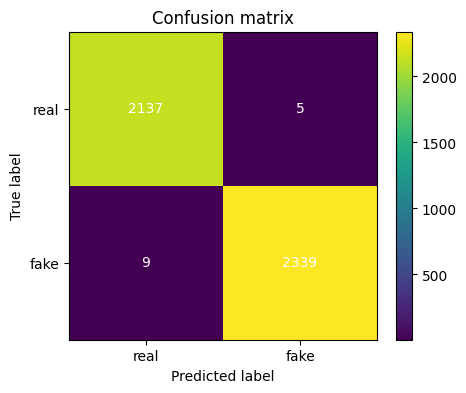

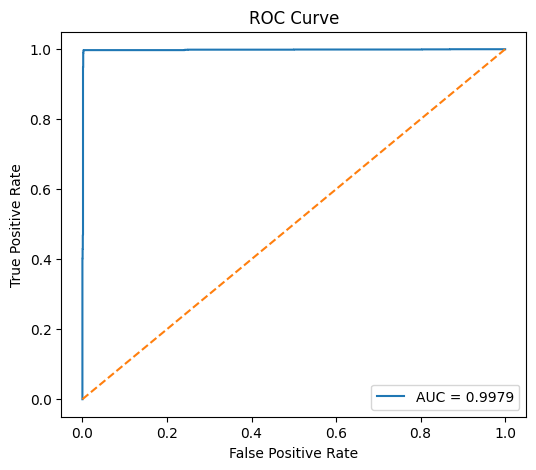

Summary: {'accuracy': 0.9968819599109131, 'precision': 0.9978668941979523, 'recall': 0.9961669505962522, 'f1': 0.9970161977834613, 'roc_auc': 0.9979449900346283, 'time_per_epoch': 141.77478901545206}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.001, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6439, val_loss=0.5386, train_f1=0.6602, val_f1=0.7382, time=452.77s
Epoch 2/3: train_loss=0.4745, val_loss=0.4831, train_f1=0.8089, val_f1=0.7972, time=421.28s
Epoch 3/3: train_loss=0.4073, val_loss=0.4751, train_f1=0.8546, val_f1=0.8167, time=403.93s

Test results:
accuracy: 0.8131403118040089
precision: 0.822298163178129
recall: 0.8198466780238501
f1: 0.8210705907442951
roc_auc: 0.8440539617323364


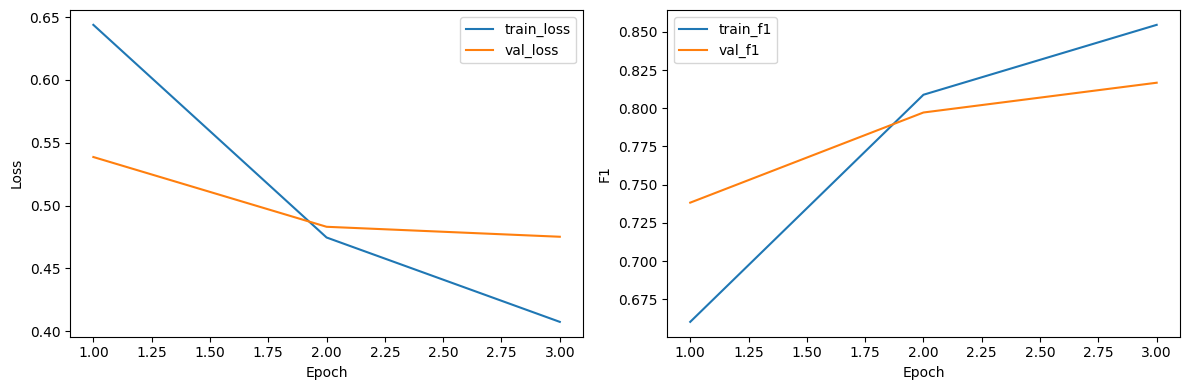

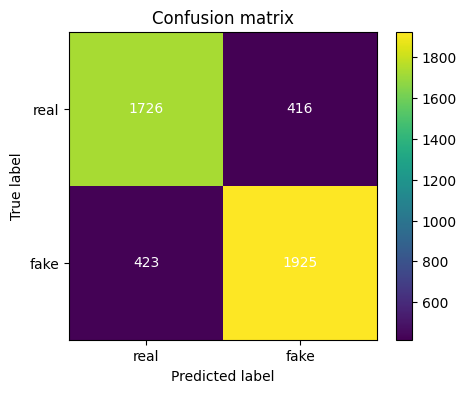

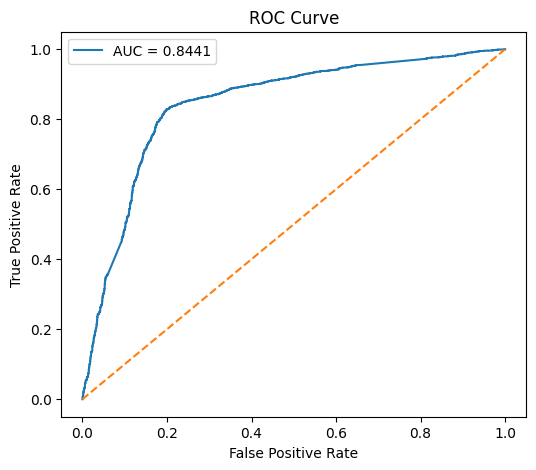

Summary: {'accuracy': 0.8131403118040089, 'precision': 0.822298163178129, 'recall': 0.8198466780238501, 'f1': 0.8210705907442951, 'roc_auc': 0.8440539617323364, 'time_per_epoch': 425.9945845603943}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.0005, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.3740, val_loss=0.1463, train_f1=0.8526, val_f1=0.9675, time=263.74s
Epoch 2/3: train_loss=0.1507, val_loss=0.0861, train_f1=0.9635, val_f1=0.9833, time=255.72s
Epoch 3/3: train_loss=0.0948, val_loss=0.0754, train_f1=0.9803, val_f1=0.9841, time=258.78s

Test results:
accuracy: 0.9799554565701559
precision: 0.9951754385964913
recall: 0.9663543441226575
f1: 0.9805531547104581
roc_auc: 0.9906858967323442


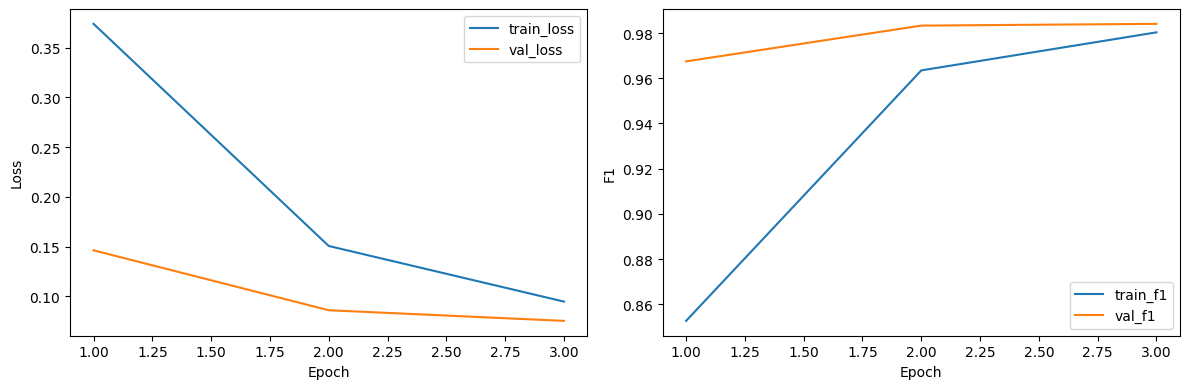

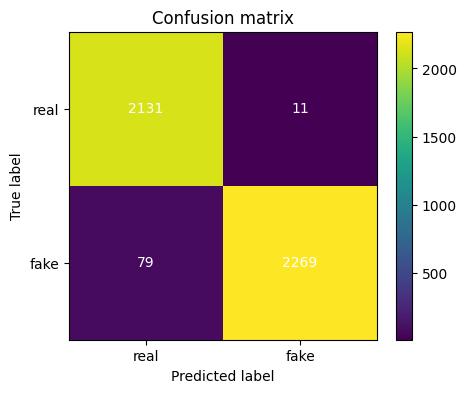

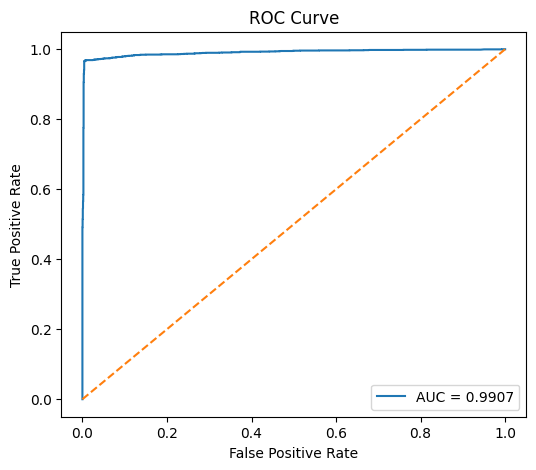

Summary: {'accuracy': 0.9799554565701559, 'precision': 0.9951754385964913, 'recall': 0.9663543441226575, 'f1': 0.9805531547104581, 'roc_auc': 0.9906858967323442, 'time_per_epoch': 259.41239643096924}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'lr': 0.0005, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6188, val_loss=0.5083, train_f1=0.7022, val_f1=0.7811, time=342.31s
Epoch 2/3: train_loss=0.4642, val_loss=0.4196, train_f1=0.8213, val_f1=0.8383, time=361.76s
Epoch 3/3: train_loss=0.4066, val_loss=0.3685, train_f1=0.8531, val_f1=0.8184, time=394.71s

Test results:
accuracy: 0.8334075723830735
precision: 0.9106776180698152
recall: 0.7555366269165247
f1: 0.8258845437616388
roc_auc: 0.9217994693618504


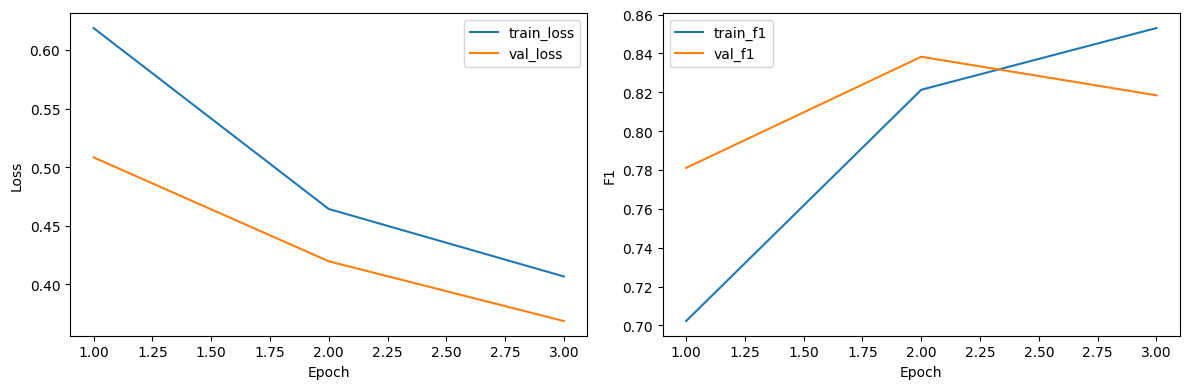

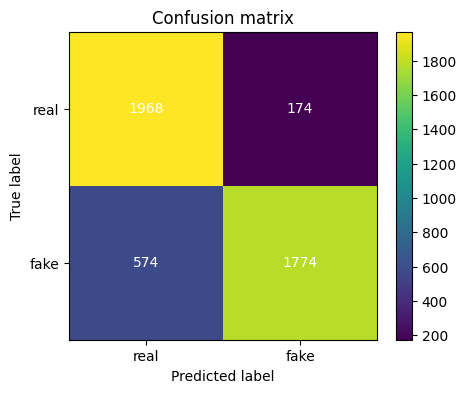

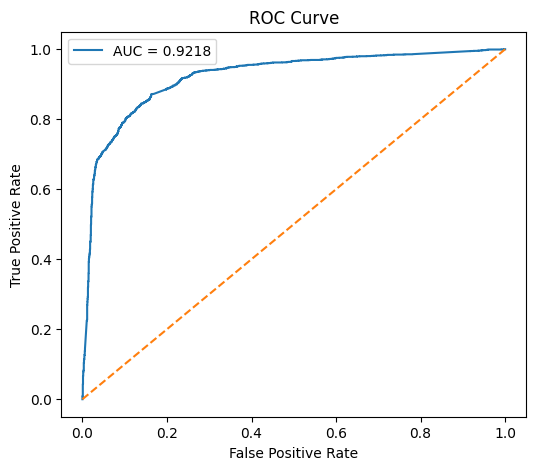

Summary: {'accuracy': 0.8334075723830735, 'precision': 0.9106776180698152, 'recall': 0.7555366269165247, 'f1': 0.8258845437616388, 'roc_auc': 0.9217994693618504, 'time_per_epoch': 366.2563810348511}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.001, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.0470, val_loss=0.0173, train_f1=0.9826, val_f1=0.9974, time=262.47s
Epoch 2/3: train_loss=0.0087, val_loss=0.0168, train_f1=0.9985, val_f1=0.9977, time=307.09s
Epoch 3/3: train_loss=0.0053, val_loss=0.0183, train_f1=0.9990, val_f1=0.9979, time=294.30s

Test results:
accuracy: 0.9986636971046771
precision: 0.9982978723404256
recall: 0.9991482112436116
f1: 0.9987228607918264
roc_auc: 0.9997458949508252


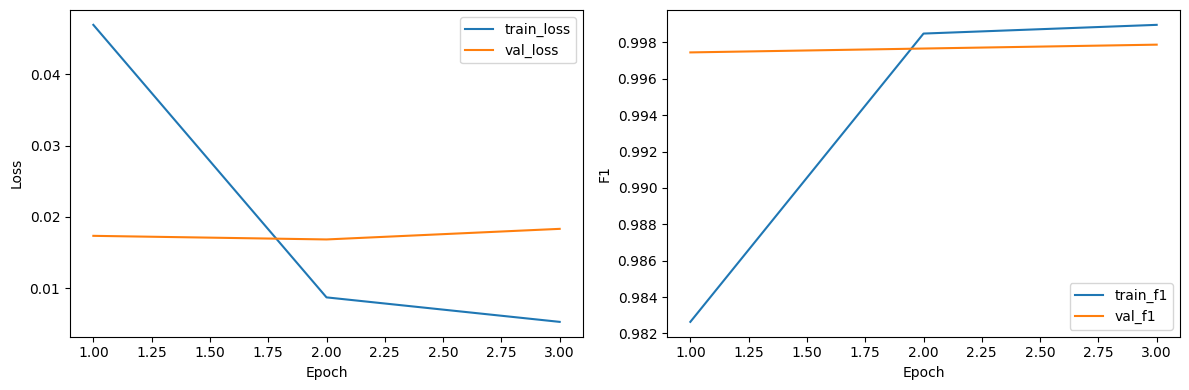

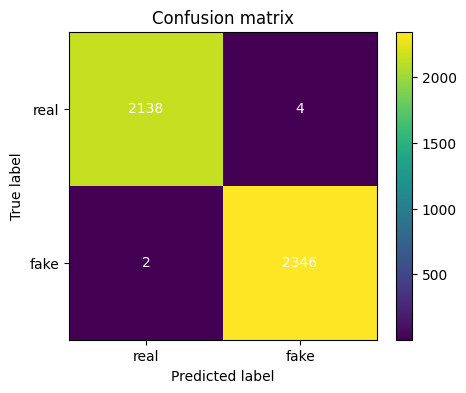

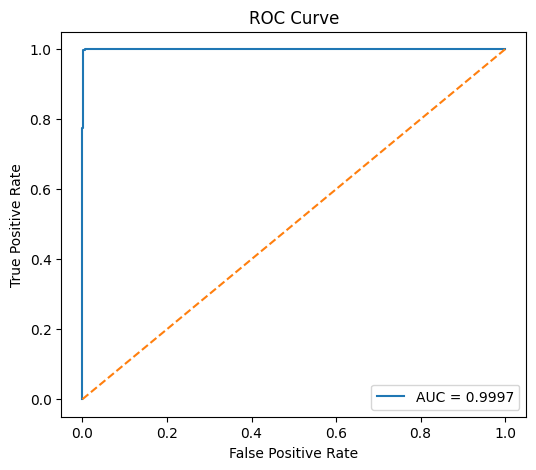

Summary: {'accuracy': 0.9986636971046771, 'precision': 0.9982978723404256, 'recall': 0.9991482112436116, 'f1': 0.9987228607918264, 'roc_auc': 0.9997458949508252, 'time_per_epoch': 287.95210496584576}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.001, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6439, val_loss=0.5386, train_f1=0.6602, val_f1=0.7382, time=401.57s
Epoch 2/3: train_loss=0.4745, val_loss=0.4831, train_f1=0.8089, val_f1=0.7972, time=380.78s
Epoch 3/3: train_loss=0.4073, val_loss=0.4751, train_f1=0.8546, val_f1=0.8167, time=255.60s

Test results:
accuracy: 0.8131403118040089
precision: 0.822298163178129
recall: 0.8198466780238501
f1: 0.8210705907442951
roc_auc: 0.8440539617323364


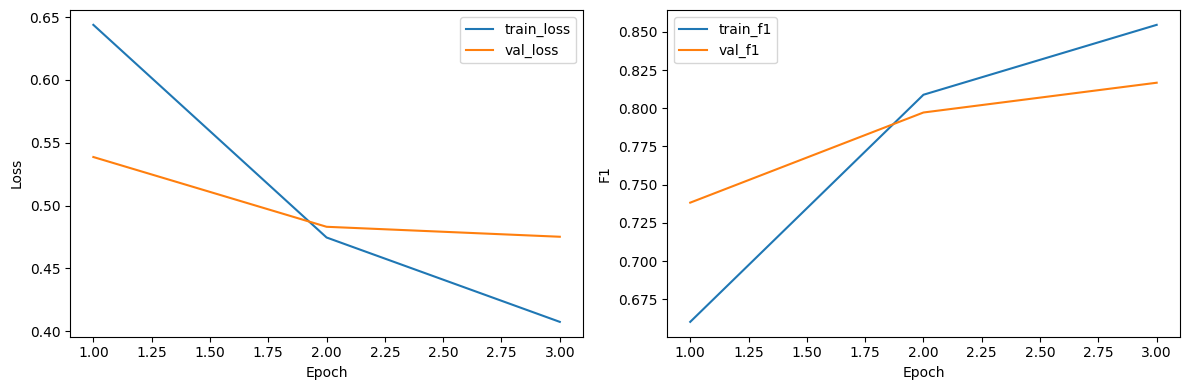

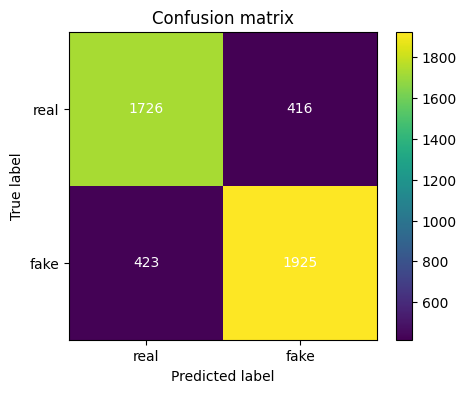

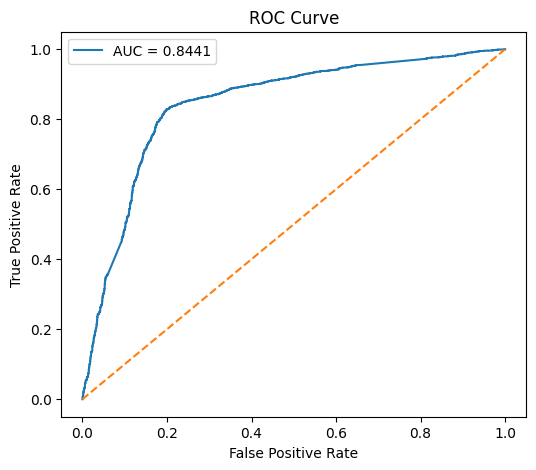

Summary: {'accuracy': 0.8131403118040089, 'precision': 0.822298163178129, 'recall': 0.8198466780238501, 'f1': 0.8210705907442951, 'roc_auc': 0.8440539617323364, 'time_per_epoch': 345.98279094696045}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.0005, 'model_type': 'lstm'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.0666, val_loss=0.0160, train_f1=0.9737, val_f1=0.9974, time=180.09s
Epoch 2/3: train_loss=0.0093, val_loss=0.0160, train_f1=0.9984, val_f1=0.9977, time=186.38s
Epoch 3/3: train_loss=0.0069, val_loss=0.0168, train_f1=0.9987, val_f1=0.9977, time=187.69s

Test results:
accuracy: 0.9984409799554566
precision: 0.9978732454274777
recall: 0.9991482112436116
f1: 0.9985103213449671
roc_auc: 0.9995416962923727


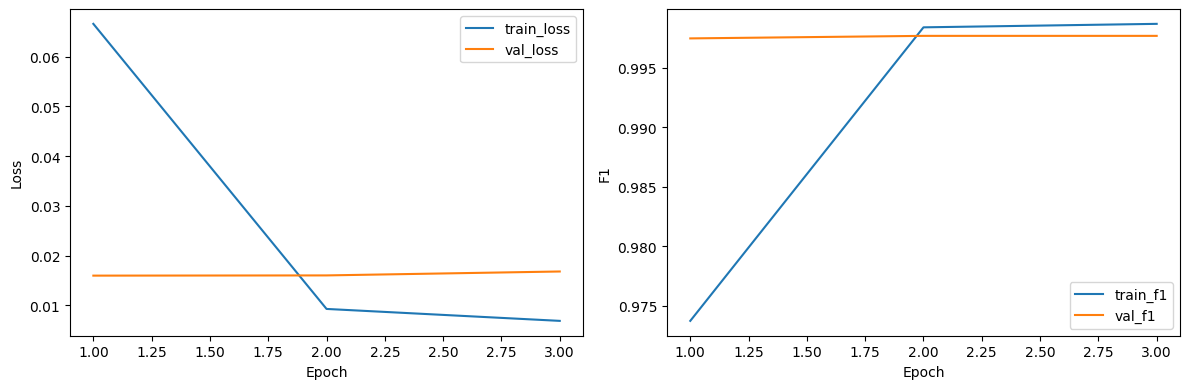

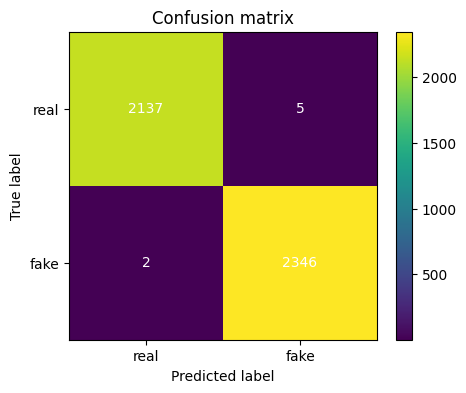

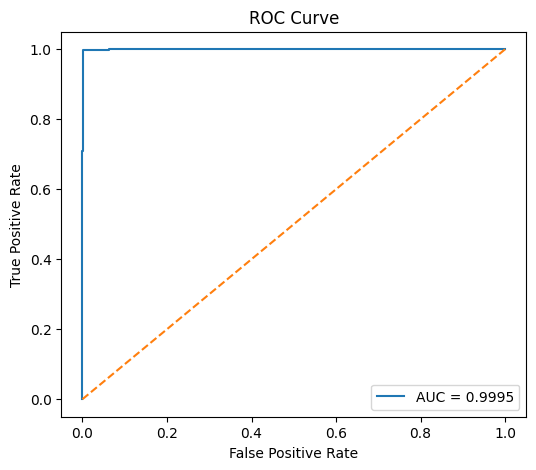

Summary: {'accuracy': 0.9984409799554566, 'precision': 0.9978732454274777, 'recall': 0.9991482112436116, 'f1': 0.9985103213449671, 'roc_auc': 0.9995416962923727, 'time_per_epoch': 184.72133962313333}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.2, 'lr': 0.0005, 'model_type': 'rnn'}
Using device: cpu
Vocab size: 5002
Epoch 1/3: train_loss=0.6188, val_loss=0.5083, train_f1=0.7022, val_f1=0.7811, time=264.19s
Epoch 2/3: train_loss=0.4642, val_loss=0.4196, train_f1=0.8213, val_f1=0.8383, time=225.74s
Epoch 3/3: train_loss=0.4066, val_loss=0.3685, train_f1=0.8531, val_f1=0.8184, time=235.40s

Test results:
accuracy: 0.8334075723830735
precision: 0.9106776180698152
recall: 0.7555366269165247
f1: 0.8258845437616388
roc_auc: 0.9217994693618504


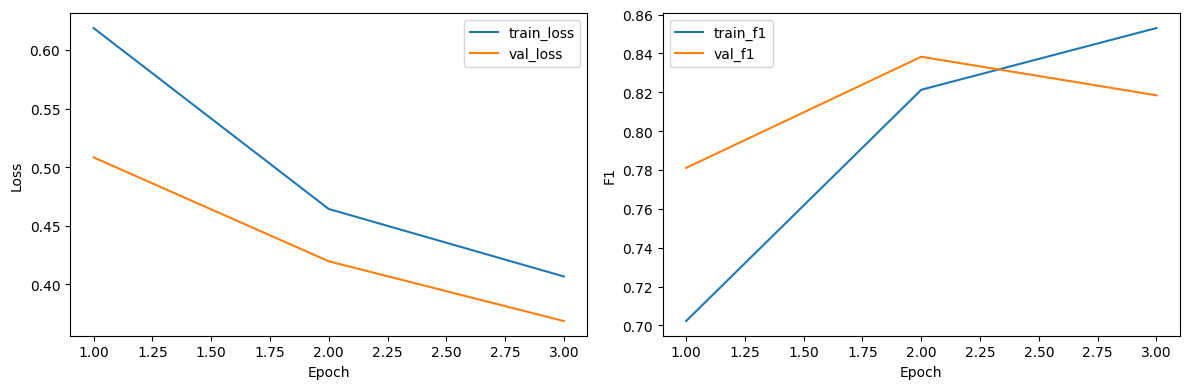

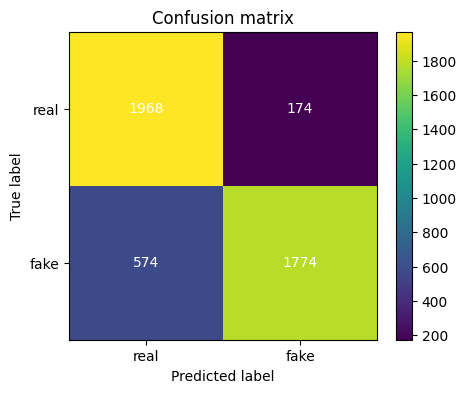

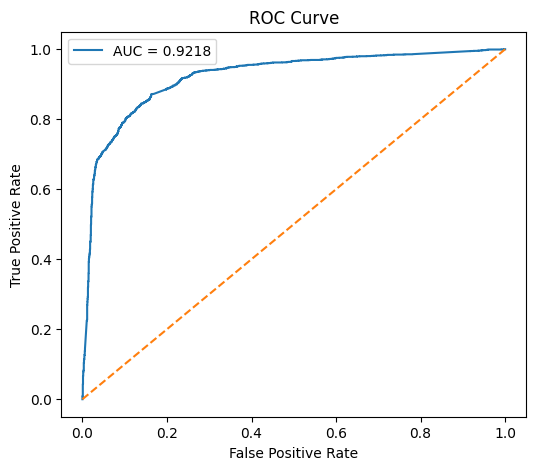

Summary: {'accuracy': 0.8334075723830735, 'precision': 0.9106776180698152, 'recall': 0.7555366269165247, 'f1': 0.8258845437616388, 'roc_auc': 0.9217994693618504, 'time_per_epoch': 241.77379441261292}

Running config: {'emb_dim': 50, 'hidden_dim': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.5, 'lr': 0.001, 'model_type': 'lstm'}
Using device: cpu


KeyboardInterrupt: 

In [14]:
# Hyperparameter grid-search helper

import itertools
grid = {
    'emb_dim': [50, 100],
    'hidden_dim': [64, 128],
    'num_layers': [1, 2],
    'bidirectional': [False, True],
    'dropout': [0.2, 0.5],
    'lr': [1e-3, 5e-4],
    'model_type': ['lstm', 'rnn']
}

run_kw = {
    'use_title_plus_text': True,
    'max_vocab': 5000,
    'max_len': 128,
    'batch_size': 16,
    'num_epochs': 3         
}

repeats = 1

keys = list(grid.keys())
all_configs = list(itertools.product(*(grid[k] for k in keys)))
records = []
for cfg in all_configs:
    cfg_dict = dict(zip(keys, cfg))
    print('\nRunning config:', cfg_dict)
    # merge cfg into run_kw
    local_kw = {**run_kw, **cfg_dict}
    agg_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'time_per_epoch': []}
    for r in range(repeats):
        set_seed(42 + r)
        out = run_pipeline(**local_kw)
        tm = out['test_metrics']
        for k in agg_metrics:
            if k == 'time_per_epoch':
                agg_metrics[k].append(np.mean(out['times_per_epoch']) if out['times_per_epoch'] else 0.0)
            else:
                agg_metrics[k].append(tm.get(k, float('nan')))
    # average
    summary = {k: float(np.nanmean(v)) for k, v in agg_metrics.items()}
    record = {'config': cfg_dict, 'summary': summary}
    records.append(record)
    print('Summary:', summary)

In [ ]:
# Висновок: Метою цієї роботи було реалізувати, натренувати та порівняти дві прості реалізації RNN та LSTM моделей на прикладі датасету з
# правдивими та фейковими новинами.

# Датасет складається з рядків: Title, Text, Subject, Date. Для роботи було конкантиновано Title та Text.

# Було реалізовано пайплайн, в якому спочатку йде токенізація та побудова словника, розподіл даних, тренування моделей та вивід результатів,
# графіків та confusion matrix.

# При наступних параметрах batch_size=16, emb_dim=100, hidden_dim=64,
                        #  num_layers=1, bidirectional=False, dropout=0.2,
                        #  lr=1e-3, num_epochs=4

# LSTM-модель видала наступні результати:
# accuracy: 0.9973273942093541 = 99,7%
# precision: 0.9991452991452991 = 99,9%
# recall: 0.995741056218058 = 99,6%
# f1: 0.9974402730375427 = 99,7%
# roc_auc: 0.9992440474202174 = 99,9 %

# Confusion Matrix:
# True label   Real 2140 2
#              Fake 10   2338
#                   Real Fake
#                  False label

# RNN-модель:
# accuracy: 0.8815144766146993 = 88,1%
# precision: 0.9344497607655502 = 93,4%
# recall: 0.8317717206132879 = 83,1%
# f1: 0.8801261829652997 = 88%
# roc_auc: 0.930343602517668 = 93%

# Confusion Matrix:
# True label   Real 2005 137
#              Fake 395  1953
#                   Real Fake
#                  False label

# Навіть при використанні гіперпараметрів: 'emb_dim': [50, 100],
                                        #  'hidden_dim': [64, 128],
                                        #  'num_layers': [1, 2],
                                        #  'bidirectional': [False, True],
                                        #  'dropout': [0.2, 0.5],
                                        #  'lr': [1e-3, 5e-4], (Я не посилив виконати при всіх комбінаціях, це би зайняло півтори дня, щоб натренувати
                                        #                       моделі 128 раз)

# RNN-модель виконує менш якісно роботу ніж LSTM.
# LSTM — покращена версія RNN, оптимізована для роботи з довгими послідовностями. 
# Вона розв’язує фундаментальні проблеми класичної RNN (насамперед затухання градієнтів) і дає значно кращі результати в задачах, 
# де важлива довготривала пам’ять.
# LSTM має спеціальну структуру memory cell + три “ворота” (input, forget, output), що може передавати інформацію на сотні кроків уперед без втрати.